In [1]:
# Cella 1 - Import librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from wordcloud import WordCloud
import re
from collections import Counter

print("✅ Librerie caricate!")

✅ Librerie caricate!


In [2]:
# Cella 2 - Carica i tuoi proverbi dal database
import sqlite3
import pandas as pd

# Connettiti al database
conn = sqlite3.connect('frasi.db')

# Carica i proverbi italiani
df_proverbi = pd.read_sql_query("""
    SELECT id, tema, proverbio, autore 
    FROM proverbi 
    ORDER BY tema
""", conn)

# Chiudi connessione
conn.close()

# Mostra le prime righe
print(f"📖 Caricati {len(df_proverbi)} proverbi")
print("\nPrime 5 righe:")
df_proverbi.head()

📖 Caricati 65 proverbi

Prime 5 righe:


,id,tema,proverbio,autore
0,25,amicizia,Chi trova un amico trova un tesoro,Proverbio
1,26,amicizia,L'amico si vede nel bisogno,Proverbio latino
2,27,amicizia,Dimmi con chi vai e ti dirò chi sei,Proverbio
3,28,amicizia,Amici pochi ma buoni,Proverbio
4,29,amicizia,Chi trova un amico trova conforto,Proverbio


In [4]:
# Cella 3 - Statistiche base
print("📊 STATISTICHE PROVERBI")
print("-" * 40)
print(f"Totale proverbi: {len(df_proverbi)}")
print(f"Temi unici: {df_proverbi['tema'].nunique()}")
print(f"Autori unici: {df_proverbi['autore'].nunique()}")

print("\n🏷️ Temi più frequenti:")
print(df_proverbi['tema'].value_counts().head(10))

📊 STATISTICHE PROVERBI
----------------------------------------
Totale proverbi: 65
Temi unici: 11
Autori unici: 9

🏷️ Temi più frequenti:
tema
amicizia    8
amore       8
lavoro      8
tempo       8
vita        8
destino     5
fortuna     5
saggezza    5
verità      4
famiglia    3
Name: count, dtype: int64


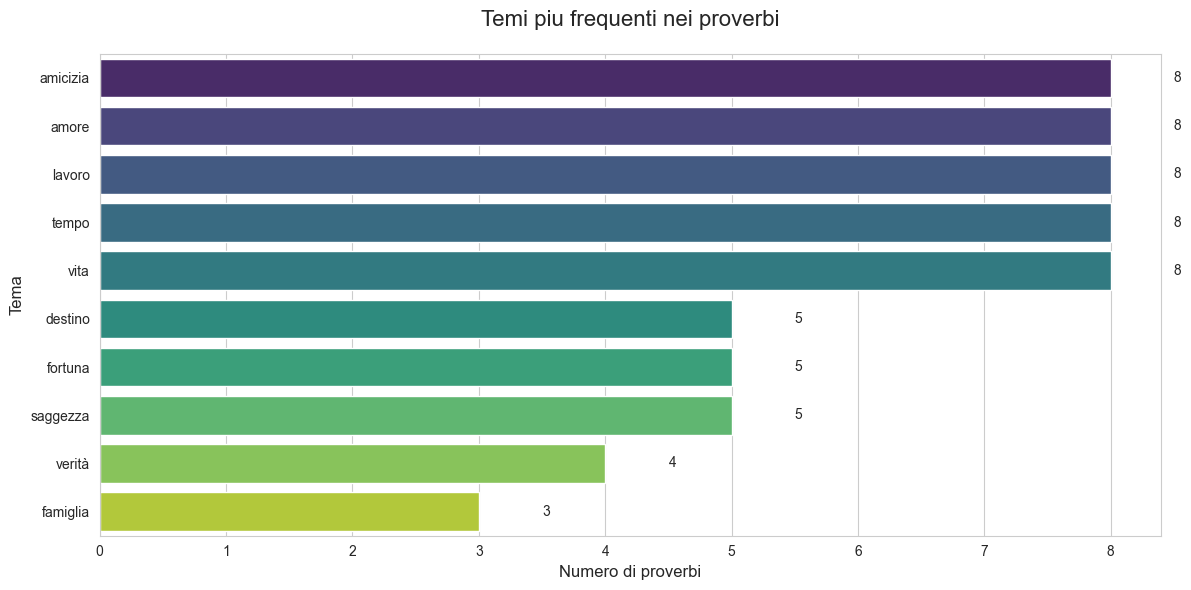


Temi con piu proverbi:
  • amicizia: 8 proverbi
  • amore: 8 proverbi
  • lavoro: 8 proverbi
  • tempo: 8 proverbi
  • vita: 8 proverbi


In [9]:
# Cella 4 - Grafico dei temi (versione senza emoji)
import matplotlib.pyplot as plt
import seaborn as sns

# Imposta lo stile
sns.set_style("whitegrid")

# Prepara i dati
temi_counts = df_proverbi['tema'].value_counts().head(10).reset_index()
temi_counts.columns = ['tema', 'conteggio']

# Crea il grafico
plt.figure(figsize=(12, 6))
bars = sns.barplot(
    data=temi_counts, 
    x='conteggio', 
    y='tema',
    hue='tema',
    palette='viridis',
    legend=False
)

# Personalizza (SENZA EMOJI)
plt.title('Temi piu frequenti nei proverbi', fontsize=16, pad=20)
plt.xlabel('Numero di proverbi', fontsize=12)
plt.ylabel('Tema', fontsize=12)

# Aggiungi i numeri sulle barre
for i, (value, name) in enumerate(zip(temi_counts['conteggio'], temi_counts['tema'])):
    plt.text(value + 0.5, i, str(value), va='center')

plt.tight_layout()
plt.show()

print("\nTemi con piu proverbi:")
for idx, row in temi_counts.head(5).iterrows():
    print(f"  • {row['tema']}: {row['conteggio']} proverbi")

📏 STATISTICHE LUNGHEZZA
------------------------------
Media: 29.0 caratteri
Mediana: 28.0 caratteri
Massimo: 55 caratteri
Minimo: 10 caratteri

📜 Proverbio più lungo (55 caratteri):
  "Amore fa passare il tempo e il tempo fa passare l'amore"
  — Proverbio (amore)

📜 Proverbio più corto (10 caratteri):
  "Carpe Diem"
  — Orazio (vita)


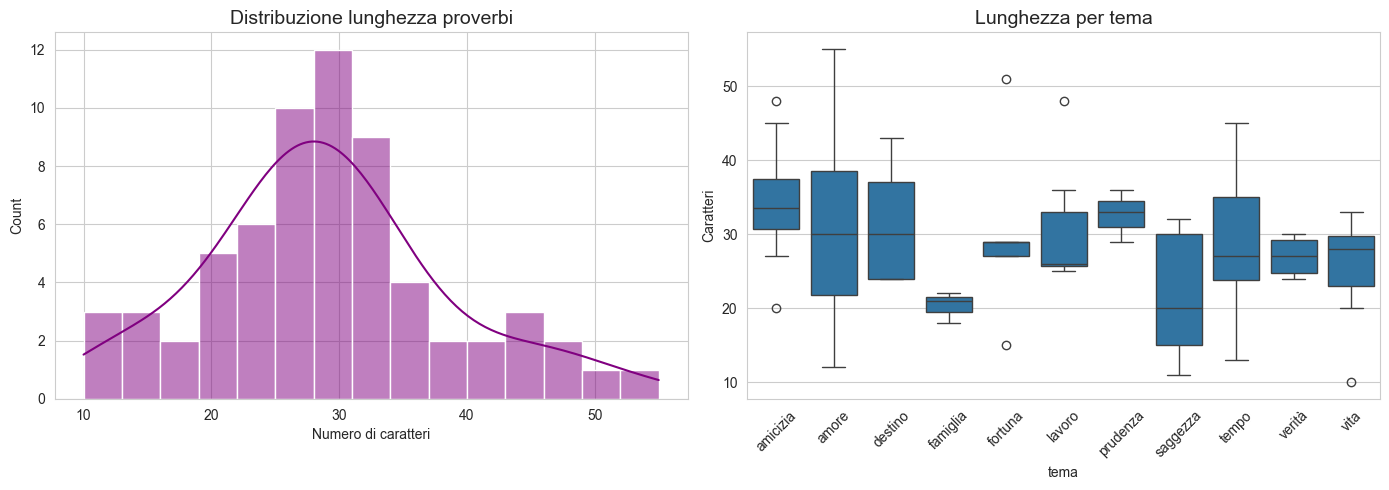

In [7]:
# Cella 5 - Analisi lunghezza
# Aggiungi colonna lunghezza
df_proverbi['lunghezza'] = df_proverbi['proverbio'].str.len()

# Statistiche
print("📏 STATISTICHE LUNGHEZZA")
print("-" * 30)
print(f"Media: {df_proverbi['lunghezza'].mean():.1f} caratteri")
print(f"Mediana: {df_proverbi['lunghezza'].median():.1f} caratteri")
print(f"Massimo: {df_proverbi['lunghezza'].max()} caratteri")
print(f"Minimo: {df_proverbi['lunghezza'].min()} caratteri")

# Trova il proverbio più lungo e più corto
piu_lungo = df_proverbi.loc[df_proverbi['lunghezza'].idxmax()]
piu_corto = df_proverbi.loc[df_proverbi['lunghezza'].idxmin()]

print(f"\n📜 Proverbio più lungo ({piu_lungo['lunghezza']} caratteri):")
print(f"  \"{piu_lungo['proverbio']}\"")
print(f"  — {piu_lungo['autore']} ({piu_lungo['tema']})")

print(f"\n📜 Proverbio più corto ({piu_corto['lunghezza']} caratteri):")
print(f"  \"{piu_corto['proverbio']}\"")
print(f"  — {piu_corto['autore']} ({piu_corto['tema']})")

# Grafico distribuzione
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_proverbi['lunghezza'], bins=15, kde=True, color='purple')
plt.title('Distribuzione lunghezza proverbi', fontsize=14)
plt.xlabel('Numero di caratteri')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_proverbi, x='tema', y='lunghezza')
plt.title('Lunghezza per tema', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Caratteri')

plt.tight_layout()
plt.show()

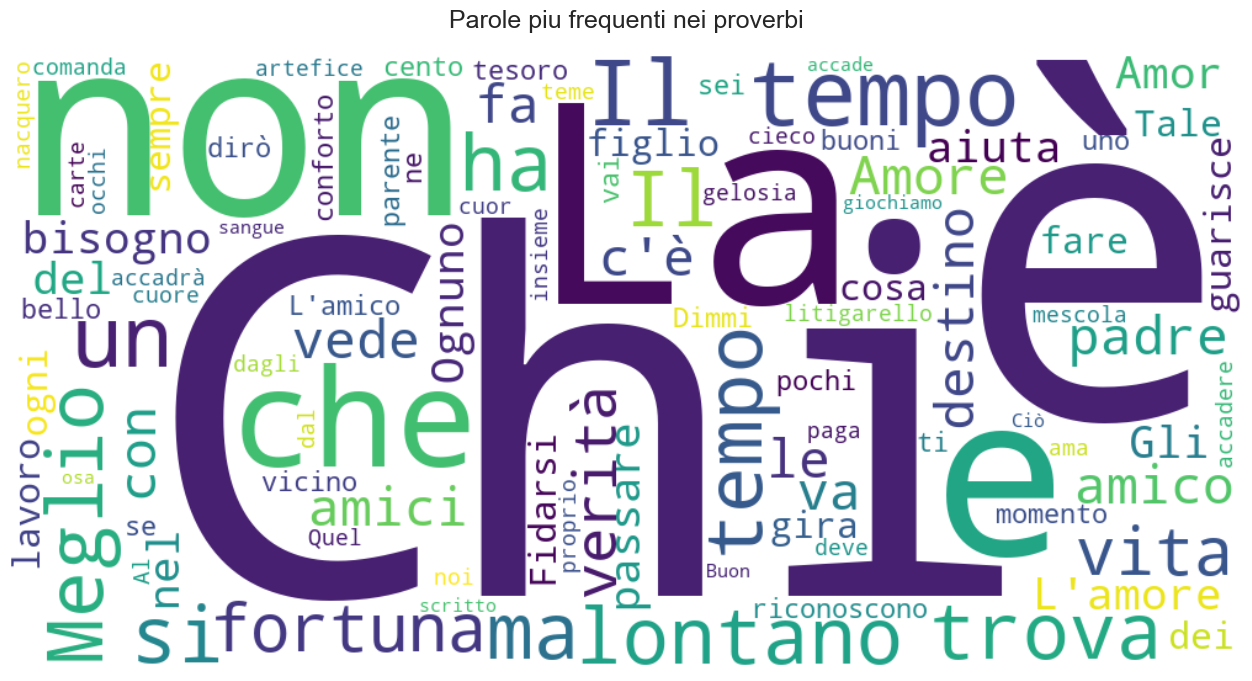

In [10]:
# Cella 6 - WordCloud (senza emoji)
from wordcloud import WordCloud

# Se non hai wordcloud, installalo in una cella:
# !pip install wordcloud

# Unisci tutti i proverbi in un unico testo
testo_completo = ' '.join(df_proverbi['proverbio'].tolist())

# Crea la wordcloud
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    colormap='viridis',
    max_words=100,
    contour_width=1,
    contour_color='steelblue',
    random_state=42
).generate(testo_completo)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Parole piu frequenti nei proverbi', fontsize=18, pad=20)  # ← Senza emoji
plt.show()

📖 Analisi tema: AMORE (8 proverbi)

Parole più frequenti:
  • amore: 5 volte
  • non: 3 volte
  • lontano: 3 volte
  • l: 2 volte
  • e: 2 volte
  • si: 2 volte
  • amor: 2 volte
  • fa: 2 volte
  • passare: 2 volte
  • il: 2 volte
  • tempo: 2 volte
  • bello: 1 volte
  • se: 1 volte
  • litigarello: 1 volte
  • gelosia: 1 volte


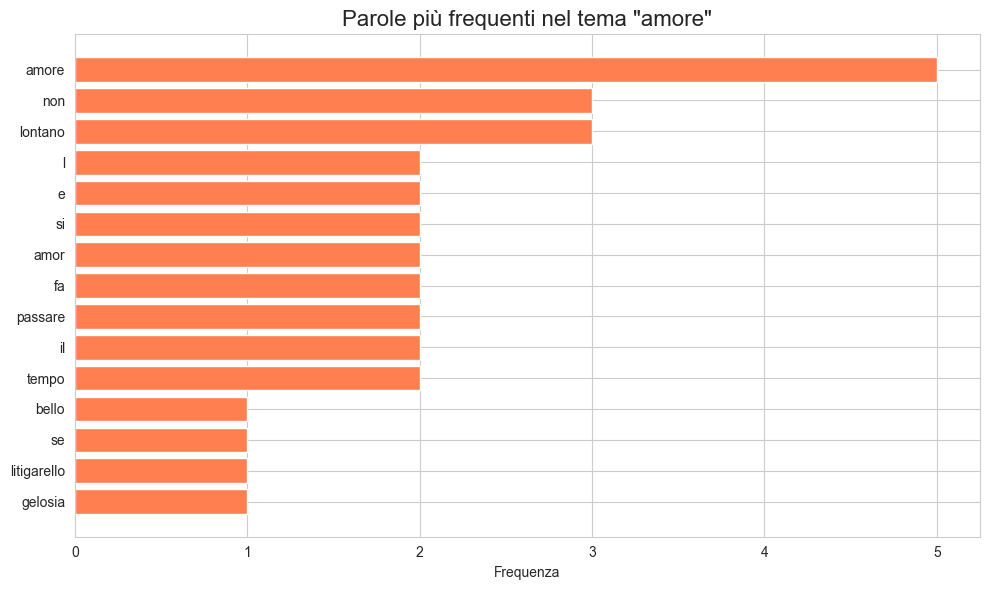

In [11]:
# Cella 7 - Parole più frequenti per tema
from collections import Counter
import re

# Scegli un tema (cambia con uno dei tuoi)
tema_scelto = 'amore'  # Puoi cambiare con 'lavoro', 'vita', ecc.

# Filtra proverbi del tema scelto
df_tema = df_proverbi[df_proverbi['tema'] == tema_scelto]

if len(df_tema) > 0:
    print(f"📖 Analisi tema: {tema_scelto.upper()} ({len(df_tema)} proverbi)")
    
    # Unisci tutti i testi
    testo_tema = ' '.join(df_tema['proverbio'].tolist()).lower()
    
    # Estrai parole (rimuovi punteggiatura)
    parole = re.findall(r'\b[a-z]+\b', testo_tema)
    
    # Conta
    parole_comuni = Counter(parole).most_common(15)
    
    print("\nParole più frequenti:")
    for parola, count in parole_comuni:
        print(f"  • {parola}: {count} volte")
    
    # Grafico
    plt.figure(figsize=(10, 6))
    parole, conteggi = zip(*parole_comuni)
    plt.barh(parole, conteggi, color='coral')
    plt.title(f'Parole più frequenti nel tema "{tema_scelto}"', fontsize=16)
    plt.xlabel('Frequenza')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"Nessun proverbio trovato per il tema '{tema_scelto}'")